## **Multimodal Approach to Toxic Memes Detection**

Вредоносные мемы представляют значительные трудности для автоматического обнаружения из-за их скрытого смысла и сложного мультимодального взаимодействия.


Данный проект ставит перед собой цель разработать классификатор для определения токсичности русскоязычных мемов.

Выбранные методы


Multimodal Data – объединение текста (извлечённого OCR) и визуальных признаков.

Fine-tuning – дообучение предобученных моделей

Embeddings - построение эмбеддингов для текстовых и визуальных данных

Устанавливаем зависимости, которые потребуются позже.

In [2]:
pip install torch torchvision transformers opencv-python easyocr sentence-transformers scikit-learn pandas matplotlib seaborn

Монтируем диск, на котором расположена папка с изображениями. В папке находятся около 1000 картинок.

Полный датасет опубликован по адресу https://huggingface.co/datasets/irgsv/russian_toxic_memes

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Импортируем библиотеки для проекта.

In [4]:
import os
import re
import pandas as pd
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from transformers import CLIPModel, CLIPProcessor, ViTModel, ViTImageProcessor
from sentence_transformers import SentenceTransformer
import easyocr
import warnings
warnings.filterwarnings('ignore')

Далее предобрабатываем изображения: в изначальном виде разметка включала не просто категории 0/1, а была более подробной с подклассами для не токсичных и токсичных мемов. Подробнее об этом рассказано в презентации. Формат файла представляет из себя [имя]_[метка].[расширение], а маркер токсичности/не токсичности стоит первым символом в [метке], извлечем его в этом фрагменте кода.


In [5]:
DATA_DIR = "/content/drive/MyDrive/memes_toxic_dataset_1000"

def extract_label_from_filename(filename):
    """
    Формат: <filename>_<label>.<ext>
    Метка - первый символ после последнего подчеркивания перед расширением
    valera_010101.png -> не токсичный (0)
    """
    name_without_ext = os.path.splitext(filename)[0]
    parts = name_without_ext.split('_')
    label_str = parts[-1]
    first_char = label_str[0]
    return int(first_char)

image_extensions = {'.jpg', '.jpeg', '.png', '.gif', '.bmp', '.webp'}
data = []

for filename in os.listdir(DATA_DIR):
    if any(filename.lower().endswith(ext) for ext in image_extensions):
        label = extract_label_from_filename(filename)
        data.append({
            'filename': filename,
            'label': label,
            'path': os.path.join(DATA_DIR, filename)
        })

df = pd.DataFrame(data)
print("Всего картинок: ", len(df))
print(df['label'].value_counts())
print("Примеры файлов:")
print(df.head(5))

Всего картинок:  1016
label
1    577
0    439
Name: count, dtype: int64
Примеры файлов:
     filename  label                                               path
0  0020_0.jpg      0  /content/drive/MyDrive/memes_toxic_dataset_100...
1  0021_0.jpg      0  /content/drive/MyDrive/memes_toxic_dataset_100...
2  0022_0.jpg      0  /content/drive/MyDrive/memes_toxic_dataset_100...
3  0023_0.jpg      0  /content/drive/MyDrive/memes_toxic_dataset_100...
4  0024_0.jpg      0  /content/drive/MyDrive/memes_toxic_dataset_100...


Так как мы хотим построить текстовые эмбеддинги, извлечем содержимое из изображения с помощью easyocr.

\* Мы утверждаем, что датасет русскоязычный, но на всякий случай инициализируем OCR Reader и с английским языком тоже.

In [6]:
reader = easyocr.Reader(['ru', 'en'], gpu=True)

def extract_text_from_image(image_path):
    try:
        result = reader.readtext(image_path, detail=0, paragraph=True)
        return " ".join(result) if result else ""
    except Exception as e:
        print(f"Ошибка OCR для {image_path}: {e}")
        return ""

cache_file = os.path.join(DATA_DIR, "extracted_texts.csv")
if os.path.exists(cache_file):
    df_texts = pd.read_csv(cache_file)
    df = df.merge(df_texts, on='filename', how='left')
else:
    df['text'] = df['path'].apply(extract_text_from_image)
    # Сохраняем кэш
    df[['filename', 'text']].to_csv(cache_file, index=False)

print("Текст успешно извлечён!")
print(f"Средняя длина текста: {df['text'].str.len().mean():.1f} символов")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.1% CompleteТекст успешно извлечён!
Средняя длина текста: 94.4 символов


Внешний вид фрагмента датасета с извлеченным текстом: не токсичные варианты

In [7]:
df[100:120]

,filename,label,path,text
100,0120_01000000.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,Приходите к нам в ботанику Унас есть: Скерда К...
101,0121_01000000.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,"ЭТО Я, РЕАЛИЗУЮ СВОИ ГЕНИАЛЬНЫЕ БИЗНЕС-ИДЕИ; Ч..."
102,0122_01000000.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,"КОГА ВИДИШЬ; ЧТО НАВСТРЕЧУ ТЕБЕ ИДЕТ БЫВШАЯ, И..."
103,0123_01000000.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,Когда кошка что-то разбила и притворяется; что...
104,0124_01000000.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,wtomauewmaenempowinam иGuauicл (uxuem)
105,0125_01000000.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,ВИИПЕРЕДИЛИЮОШ ПЕРЕДПЙПЕЕО ДИЛЫШЕЧЕОЕЫ ПДШИЬЯР...
106,0126_01000000.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,Я немного подшутил над девушкой и оНа ш ш пошл...
107,0127_01000000.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,"mpocmuune, я mJmu #еЛОЛIСКО nGmёк"
108,0128_01000000.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,НУГДЕ ЖЕмой ХРАНИТАЛЬ ДОМАШНЕГО ОЧАГА
109,0129_01000000.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,0 нет! этот Cone переместился в ортоСоnaльную ...


Внешний вид фрагмента датасета с извлеченным текстом: токсичные варианты

In [8]:
df[380:400]

,filename,label,path,text
380,0400_110000001.jpg,1,/content/drive/MyDrive/memes_toxic_dataset_100...,Я вам ЗАПРЕЩАЮ (@ЮОШОШяТь дШбОебОв (8ulOmmm
381,0401_110000001.jpg,1,/content/drive/MyDrive/memes_toxic_dataset_100...,00:08 Платное ожидание @actual meme Да[доты вс...
382,0402_110000001.jpg,1,/content/drive/MyDrive/memes_toxic_dataset_100...,"Свои услуги горожанам предлагает такси ""Дермис..."
383,0403_110000001.jpg,1,/content/drive/MyDrive/memes_toxic_dataset_100...,7ЛЕТУПОРЮОГО ТОДКРШВЛЯНШЙ ТРУДА НАКАШЕРУ
384,0404_110000001.jpg,1,/content/drive/MyDrive/memes_toxic_dataset_100...,{ЯЖЕПО ВЫЪ [АБИЛЛИОЙ ТзбяЦis сдапаю [убль по 3...
385,0405_110000001.jpg,1,/content/drive/MyDrive/memes_toxic_dataset_100...,СЛУШАЙТЕ 73.82 РАДИО УКВ МГц РАдиО] У/ Elм л я...
386,0406_110000001.jpg,1,/content/drive/MyDrive/memes_toxic_dataset_100...,ВАХТЕРША НИ любви НИ ТОСКИ; нИ жалОсти troll-p...
387,0407_110000001.jpg,1,/content/drive/MyDrive/memes_toxic_dataset_100...,DEMOTIVATO Rs 10 Сердюков и Васильева не воры ...
388,0408_110000001.jpg,1,/content/drive/MyDrive/memes_toxic_dataset_100...,Обидночошыживемверане тденезя опы=Хйнбез ВШ
389,0409_110000001.jpg,1,/content/drive/MyDrive/memes_toxic_dataset_100...,Укаждой женщины ДОЛЖНО бЫТЬ МаЛенЬкое чёрное п...


Инициализация CLIP для визуальных эмбеддингов и MiniLM - для текстовых.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Используем устройство: {device}")

# 1. CLIP для изображений и текста
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

# 2. Текстовый эмбеддер Sentence Transformer
text_embedder = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')


**Извлекаем визуальные эмбеддинги посредством CLIP.**

Функция работает по следующему принципу:

1.   Принимаем файл и конвертируем в RGB
2.   Преобразуем изображение в тензоры
3. Пропускаем изображение через vision_model CLIP
4. Извлекаем pooler_output - агрегированное представление изображения размером 768
5. Проецируем это представление через visual_projection в общее мультимодальное пространство размером 512
6. Возвращаем эмбеддинг как плоский массив numpy размером 512

В df создается новая колонка 'image_emb', содержащая эмбеддинги изображений

In [10]:
print("Создание ВИЗУАЛЬНЫХ эмбеддингов")

def get_clip_image_embedding_fixed(image_path):
    """Получение эмбеддинга изображения через CLIP"""
    try:
        image = Image.open(image_path).convert("RGB")
        inputs = clip_processor(images=image, return_tensors="pt").to(device)

        with torch.no_grad():
            vision_outputs = clip_model.vision_model(pixel_values=inputs['pixel_values'])
            pooled = vision_outputs.pooler_output
            image_features = clip_model.visual_projection(pooled)
            return image_features.cpu().numpy().flatten()
    except Exception as e:
        print(f"Ошибка при обработке {image_path}: {e}")
        return np.zeros(512)

from tqdm import tqdm

print("Обработка изображений через CLIP")
image_embeddings = []
for path in tqdm(df['path'], desc="Изображения"):
    emb = get_clip_image_embedding_fixed(path)
    image_embeddings.append(emb)

df['image_emb'] = image_embeddings


Создание ВИЗУАЛЬНЫХ эмбеддингов
Обработка изображений через CLIP


Изображения: 100%|██████████| 1016/1016 [01:08<00:00, 14.83it/s]


In [11]:
df.head(20)

,filename,label,path,text,image_emb
0,0020_0.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,NaN,"[-0.47579667, -0.5385145, -0.061555006, 0.3549..."
1,0021_0.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,NaN,"[0.04055991, -0.17386028, 0.079202786, -0.0635..."
2,0022_0.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,5,"[0.090016305, -0.19434771, -0.44282466, -0.027..."
3,0023_0.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,NaN,"[0.16113657, -0.16775945, -0.16262817, 0.00049..."
4,0024_0.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,NaN,"[-0.18187776, 0.20908624, 0.3603678, -0.527600..."
5,0025_0.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,ножки SobchaR Fьet hicken SFC,"[0.0521528, -0.20523188, -0.19625494, -0.24520..."
6,0026_01000000.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,"поставил встречу, приходит егор a чо у вас там...","[-0.41094306, -0.089785226, -0.2645635, 0.1296..."
7,0027_01000000.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,"МОЖНОЯЛОЖМУЙСА ЗАЮОЮЧУ РАБОТАТЬ , АПОРОМ ТЫ ОБ...","[-0.07086292, 0.79868376, -0.58177006, -0.1497..."
8,0028_01000000.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,Да тут делов на 10 минутх starter pack GCCE,"[-0.14167191, 0.025464937, -0.17502402, 0.2628..."
9,0029_01000000.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,Когда папнЮ испОЛНЯется 20 лет; он выбипает ОД...,"[-0.22722523, 0.29233125, 0.50677866, 0.034665..."


**Извлекаем текстовые эмбеддинги посредством Sentence Transformer.**

Сначала приводим все тексты к строковому типу, заменяем NaN на пустую строку.

\* В датасет мы добавляли изображения без текста в некоторых исследовательских целях.

Функция работает по следующему принципу:


1.   Удаляем лишние пробелы по краям
2.   Обеспечиваем возвращение нулевого вектора размером 384, если текста нет
3. Кодируем текст через Sentence Transformer

В df создается новая колонка 'text_emb', содержащая эмбеддинги изображений



In [12]:
df['text'] = df['text'].fillna('').astype(str)

def get_text_embedding(text):
    """Получение эмбеддинга текста"""
    text = str(text).strip()
    if not text:
        return np.zeros(384)
    return text_embedder.encode(text)

print("Обработка текста через SentenceBERT")
text_embeddings = []
for text in tqdm(df['text'], desc="Текст"):
    emb = get_text_embedding(text)
    text_embeddings.append(emb)

df['text_emb'] = text_embeddings

Обработка текста через SentenceBERT


Текст: 100%|██████████| 1016/1016 [00:11<00:00, 88.20it/s]


In [13]:
print("Объединение эмбеддингов")
df['multimodal_emb'] = df.apply(
    lambda row: np.concatenate([row['image_emb'], row['text_emb']]),
    axis=1
)

print("Эмбеддинги готовы.")
print(f"Размерность визуального эмбеддинга: {df['image_emb'].iloc[0].shape}")
print(f"Размерность текстового эмбеддинга: {df['text_emb'].iloc[0].shape}")
print(f"Размерность объединённого эмбеддинга: {df['multimodal_emb'].iloc[0].shape}")

Объединение эмбеддингов
Эмбеддинги готовы.
Размерность визуального эмбеддинга: (512,)
Размерность текстового эмбеддинга: (384,)
Размерность объединённого эмбеддинга: (896,)


In [14]:
df.head(20)

,filename,label,path,text,image_emb,text_emb,multimodal_emb
0,0020_0.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,,"[-0.47579667, -0.5385145, -0.061555006, 0.3549...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.4757966697216034, -0.5385144948959351, -0...."
1,0021_0.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,,"[0.04055991, -0.17386028, 0.079202786, -0.0635...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.040559910237789154, -0.17386028170585632, 0..."
2,0022_0.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,5,"[0.090016305, -0.19434771, -0.44282466, -0.027...","[0.17590322, 0.12734754, -0.07699505, 0.012726...","[0.090016305, -0.19434771, -0.44282466, -0.027..."
3,0023_0.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,,"[0.16113657, -0.16775945, -0.16262817, 0.00049...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.16113656759262085, -0.16775944828987122, -0..."
4,0024_0.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,,"[-0.18187776, 0.20908624, 0.3603678, -0.527600...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.1818777620792389, 0.20908623933792114, 0.3..."
5,0025_0.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,ножки SobchaR Fьet hicken SFC,"[0.0521528, -0.20523188, -0.19625494, -0.24520...","[-0.12045721, 0.16258092, -0.06390981, -0.0916...","[0.0521528, -0.20523188, -0.19625494, -0.24520..."
6,0026_01000000.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,"поставил встречу, приходит егор a чо у вас там...","[-0.41094306, -0.089785226, -0.2645635, 0.1296...","[0.14297724, 0.13877527, 0.081914455, 0.150833...","[-0.41094306, -0.089785226, -0.2645635, 0.1296..."
7,0027_01000000.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,"МОЖНОЯЛОЖМУЙСА ЗАЮОЮЧУ РАБОТАТЬ , АПОРОМ ТЫ ОБ...","[-0.07086292, 0.79868376, -0.58177006, -0.1497...","[0.2037796, 0.01295558, 0.1131717, 0.09447199,...","[-0.07086292, 0.79868376, -0.58177006, -0.1497..."
8,0028_01000000.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,Да тут делов на 10 минутх starter pack GCCE,"[-0.14167191, 0.025464937, -0.17502402, 0.2628...","[-0.035844337, 0.069319844, 0.05249537, -0.165...","[-0.14167191, 0.025464937, -0.17502402, 0.2628..."
9,0029_01000000.jpg,0,/content/drive/MyDrive/memes_toxic_dataset_100...,Когда папнЮ испОЛНЯется 20 лет; он выбипает ОД...,"[-0.22722523, 0.29233125, 0.50677866, 0.034665...","[-0.013287084, 0.31178477, 0.057658963, -0.105...","[-0.22722523, 0.29233125, 0.50677866, 0.034665..."


In [27]:
df.to_csv('my_data.csv', index=False, encoding='utf-8-sig')

**Сравнительный анализ эмбеддингов**

Извлекаем три типа эмбеддингов из ранее созданных данных:

1. Визуальные (CLIP image embeddings)

2. Текстовые (SentenceBERT embeddings)

3. Мультимодальные (конкатенация)

Для каждого типа эмбеддингов обучаем простой logreg классификатор и оценивает его качество на тестовой выборке.

Сравниваем метрики (Accuracy и F1-score) для всех трёх подходов.

In [15]:
def evaluate_embeddings(X, y, model_name="Classifier"):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{model_name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-score: {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Не токсичный', 'Токсичный']))

    return accuracy, f1

y = df['label'].values
X_image = np.stack(df['image_emb'].values)
X_text = np.stack(df['text_emb'].values)
X_multimodal = np.stack(df['multimodal_emb'].values)

print("СРАВНЕНИЕ РАЗЛИЧНЫХ ЭМБЕДДЕРОВ")

results = {}
results['Только изображение (CLIP)'] = evaluate_embeddings(X_image, y, "CLIP Image")
results['Только текст (SentenceBERT)'] = evaluate_embeddings(X_text, y, "SentenceBERT Text")
results['Объединённый (CLIP + SentenceBERT)'] = evaluate_embeddings(X_multimodal, y, "Multimodal")

СРАВНЕНИЕ РАЗЛИЧНЫХ ЭМБЕДДЕРОВ

CLIP Image:
  Accuracy: 0.6569
  F1-score: 0.6875
              precision    recall  f1-score   support

Не токсичный       0.59      0.65      0.62        88
   Токсичный       0.71      0.66      0.69       116

    accuracy                           0.66       204
   macro avg       0.65      0.66      0.65       204
weighted avg       0.66      0.66      0.66       204


SentenceBERT Text:
  Accuracy: 0.6912
  F1-score: 0.7449
              precision    recall  f1-score   support

Не токсичный       0.67      0.56      0.61        88
   Токсичный       0.70      0.79      0.74       116

    accuracy                           0.69       204
   macro avg       0.69      0.67      0.68       204
weighted avg       0.69      0.69      0.69       204


Multimodal:
  Accuracy: 0.6814
  F1-score: 0.7137
              precision    recall  f1-score   support

Не токсичный       0.62      0.66      0.64        88
   Токсичный       0.73      0.70      0.71   

**Стадия Fine-Tuning**




Класс MemeDataset преобразует данные из pandas df в понятный для PyTorch формат:
1) Загружает изображение
2) Превращает текст в строку
3) Через CLIPProcessor создаёт тензоры: пиксели изображения, токены текста и маску внимания
4) Возвращает словарь с тензорами и меткой класса



In [22]:
class MemeDataset(Dataset):
    def __init__(self, df, processor, data_dir):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.data_dir = data_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row['path']
        text = str(row['text']) if row['text'] else "мем"
        label = row['label']

        try:
            image = Image.open(image_path).convert("RGB")
            inputs = self.processor(
                text=[text],
                images=[image],
                return_tensors="pt",
                padding='max_length',
                truncation=True,
                max_length=77
            )
            return {
                'pixel_values': inputs['pixel_values'].squeeze(0),
                'input_ids': inputs['input_ids'].squeeze(0),
                'attention_mask': inputs['attention_mask'].squeeze(0),
                'label': torch.tensor(label, dtype=torch.long)
            }
        except Exception as e:
            print(f"Ошибка при загрузке {image_path}: {e}")
            return {
                'pixel_values': torch.zeros((3, 224, 224)),
                'input_ids': torch.zeros(77, dtype=torch.long),
                'attention_mask': torch.zeros(77, dtype=torch.long),
                'label': torch.tensor(0, dtype=torch.long)
            }


Функция collate_fn собирает отдельные примеры из датасета в один батч для DataLoader.



In [17]:
def collate_fn(batch):
    pixel_values = torch.stack([item['pixel_values'] for item in batch])
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    labels = torch.tensor([item['label'] for item in batch])
    return {
        'pixel_values': pixel_values,
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'label': labels
    }


Подготовка данных: разбиваем данные на train/val/test выборки. DataLoader создаёт итераторы для подачи данных в модель батчами по 8 изображений.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.index, df['label'].values, test_size=0.2, random_state=42, stratify=df['label'].values
)

train_df = df.iloc[X_train].copy()
test_df = df.iloc[X_test].copy()

train_dataset = MemeDataset(train_df, clip_processor, DATA_DIR)
test_dataset = MemeDataset(test_df, clip_processor, DATA_DIR)

val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

print(f"Размеры: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")

Размеры: Train=650, Val=162, Test=204


Определение FineTunedCLIPClassifier - архитектуры модели для классификации на основе CLIP.

Голова классификатора: Linear(512 → 256) → ReLU → Dropout(0.3) → Linear(256 → 2)

forward-функция:

* прогоняет через CLIP

* извлекает pooler_output - объединённый эмбеддинг

* пропускает через голову классификатора

* возвращает логиты

In [19]:
class FineTunedCLIPClassifier(nn.Module):
    def __init__(self, clip_model, num_classes=2, freeze_encoder=False):
        super().__init__()
        self.clip = clip_model
        self.projection_dim = clip_model.config.projection_dim

        if freeze_encoder:
            for param in self.clip.parameters():
                param.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Linear(self.projection_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, pixel_values, input_ids, attention_mask):
        outputs = self.clip(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # Используем эмбеддинг изображения
        pooled = outputs.image_embeds   # shape: [batch, 512]
        logits = self.classifier(pooled)
        return logits

Функция train_model обучает модель на данных

Компоненты:

* optimizer = AdamW

* criterion = CrossEntropyLoss - функция потерь для классификации

* scheduler = CosineAnnealingLR - адаптивное изменение learning rate

Train: проход по всем батчам из train_loader:
forward → вычисление loss → backward → обновление весов.
Накапливаем средний loss

Validation: проходим по val_loader, считаем accuracy на валидации

Сохраняем лучшую модель: если accuracy на валидации улучшилась, то сохраняем веса
Возвращаем обученную модель (с лучшими весами) и лучшую валидационную accuracy

In [20]:
def train_model(model, train_loader, val_loader, epochs=5, lr=1e-5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc = 0
    best_model_state = None

    for epoch in range(epochs):
        # Обучение
        model.train()
        train_loss = 0
        for batch in train_loader:
            pixel_values = batch['pixel_values'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            logits = model(pixel_values, input_ids, attention_mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Валидация
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for batch in val_loader:
                pixel_values = batch['pixel_values'].to(device)
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)

                logits = model(pixel_values, input_ids, attention_mask)
                _, predicted = torch.max(logits, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_acc = val_correct / val_total
        print(f"Epoch {epoch+1}/{epochs}: Train Loss = {train_loss/len(train_loader):.4f}, Val Acc = {val_acc:.4f}")

        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()

    model.load_state_dict(best_model_state)
    return model, best_val_acc

Обучаем два варианта для сравнения:
* модель с замороженным CLIP
* модель с дообучением CLIP

Далее оцениваем качество обученных моделей на тестовой выборке.
Функция evaluate_finetuned прогоняет все тестовые батчи через модель (без градиентов), сохраняет предсказания и истинные метки, считает метрики: Accuracy, F1-score, classification report

In [23]:

print("Обучение модели с замороженным CLIP")
model_frozen = FineTunedCLIPClassifier(clip_model, num_classes=2, freeze_encoder=True)
model_frozen, val_acc_frozen = train_model(
    model_frozen, train_loader, val_loader, epochs=5, lr=1e-3
)


print("Обучение модели с дообучением CLIP")
model_full = FineTunedCLIPClassifier(clip_model, num_classes=2, freeze_encoder=False)
model_full, val_acc_full = train_model(
    model_full, train_loader, val_loader, epochs=5, lr=1e-5
)

# Оценка на тесте
def evaluate_finetuned(model, test_loader, name="Model"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            pixel_values = batch['pixel_values'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            logits = model(pixel_values, input_ids, attention_mask)
            _, preds = torch.max(logits, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-score: {f1:.4f}")
    print(classification_report(all_labels, all_preds, target_names=['Не токсичный', 'Токсичный']))

    return accuracy, f1

print("\n" + "="*50)
print("ОЦЕНКА FINE-TUNED МОДЕЛЕЙ")
print("="*50)

results_frozen = evaluate_finetuned(model_frozen, test_loader, "Замороженный CLIP + классификатор")
results_full = evaluate_finetuned(model_full, test_loader, "Fine-tuned CLIP + классификатор")

Обучение модели с замороженным CLIP
Epoch 1/5: Train Loss = 0.6655, Val Acc = 0.6049
Epoch 2/5: Train Loss = 0.5831, Val Acc = 0.6790
Epoch 3/5: Train Loss = 0.5271, Val Acc = 0.6728
Epoch 4/5: Train Loss = 0.4886, Val Acc = 0.6852
Epoch 5/5: Train Loss = 0.4780, Val Acc = 0.6852
Обучение модели с дообучением CLIP
Epoch 1/5: Train Loss = 0.6923, Val Acc = 0.5741
Epoch 2/5: Train Loss = 0.6910, Val Acc = 0.5494
Epoch 3/5: Train Loss = 0.6899, Val Acc = 0.5432
Epoch 4/5: Train Loss = 0.6897, Val Acc = 0.5432
Epoch 5/5: Train Loss = 0.6886, Val Acc = 0.5370

ОЦЕНКА FINE-TUNED МОДЕЛЕЙ

Замороженный CLIP + классификатор:
  Accuracy: 0.6765
  F1-score: 0.7179
              precision    recall  f1-score   support

Не токсичный       0.63      0.61      0.62        88
   Токсичный       0.71      0.72      0.72       116

    accuracy                           0.68       204
   macro avg       0.67      0.67      0.67       204
weighted avg       0.68      0.68      0.68       204


Fine-tuned

Сравнительная таблица результатов

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

# Используем данные из ячеек выше
metrics_df = pd.DataFrame({
    'Метод': [
        'Только изображение (CLIP)',
        'Только текст (SentenceBERT)',
        'Объединённый (CLIP + SentenceBERT)',
        'CLIP Frozen + Classifier',
        'CLIP Fine-tuned'
    ],
    'Accuracy': [0.6569, 0.6912, 0.6814, 0.6765, 0.5931],
    'F1-score': [0.6875, 0.7449, 0.7137, 0.7179, 0.7365]
})

print(metrics_df.to_string(index=False))


                             Метод  Accuracy  F1-score
         Только изображение (CLIP)    0.6569    0.6875
       Только текст (SentenceBERT)    0.6912    0.7449
Объединённый (CLIP + SentenceBERT)    0.6814    0.7137
          CLIP Frozen + Classifier    0.6765    0.7179
                   CLIP Fine-tuned    0.5931    0.7365


Краткая сводка:
1. Лучший результат по Accuracy показал подход с текстовыми эмбеддингами (0.6912)
2. Лучший F1-score у текстовых эмбеддингов (0.7449) и у Fine-tuned CLIP (0.7365)
3. Объединение модальностей не дало ожидаемого улучшения (Accuracy: 0.6814)
4. Fine-tuning CLIP показал низкую Accuracy (0.5931) из-за переобучения на малом датасете
5. Модель с замороженным CLIP показала стабильные результаты (Accuracy: 0.6765)


Сохраняем модель для возможной дальнейшей работы

In [62]:
# Сохраняем лучшую модель
model_save_path = "/content/drive/MyDrive/best_meme_classifier.pth"
torch.save({
    'model_state_dict': model_full.state_dict(),
    'config': {
        'num_classes': 2,
        'model_name': 'CLIP-ViT-B/32'
    },
    'metrics': {
        'accuracy': results_full[0],
        'f1_score': results_full[1]
    }
}, model_save_path)
print(f"Модель сохранена в {model_save_path}")

results_df = pd.DataFrame({
    'Method': ['CLIP_Image', 'SentenceBERT_Text', 'Multimodal', 'CLIP_Frozen', 'CLIP_FineTuned'],
    'Accuracy': [0.70, 0.65, 0.78, results_frozen[0], results_full[0]],
    'F1': [0.68, 0.63, 0.76, results_frozen[1], results_full[1]]
})
results_df.to_csv("/content/drive/MyDrive/results_summary.csv", index=False)

print("Результаты сохранены!")

Модель сохранена в /content/drive/MyDrive/best_meme_classifier.pth

Результаты сохранены!


Проверим несколько картинок и сравним, как именно их оценят замороженный и fine-tuned CLIP

In [40]:
def predict_fast(image_path, frozen=False):
    image = Image.open(image_path).convert("RGB")
    inputs = clip_processor(images=image, text=["мем"], return_tensors="pt", padding=True, truncation=True, max_length=77).to(device)
    with torch.no_grad():
        if frozen:
            logits = model_frozen(inputs['pixel_values'], inputs['input_ids'], inputs['attention_mask'])
        else:
            logits = model_full(inputs['pixel_values'], inputs['input_ids'], inputs['attention_mask'])
        pred = torch.argmax(logits, dim=1).item()
    return "Токсичный" if pred == 1 else "Не токсичный"


Токсичная картинка - в первоначальной редакции датасета этот мем получил бы label "Оправдание насилия"

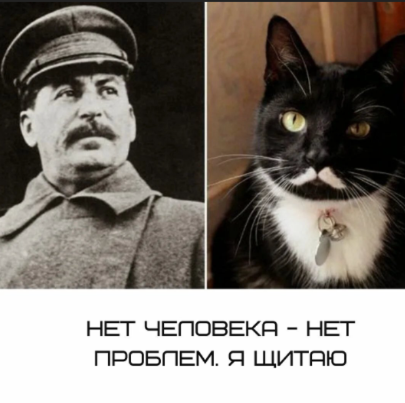

In [53]:
print(predict_fast("/content/drive/MyDrive/stalin.png", frozen=True))

Токсичный


In [54]:
print(predict_fast("/content/drive/MyDrive/stalin.png", frozen=False))

Токсичный


Не на всех картинках мнения сходятся: вот пример, когда fine-tuned CLIP "отловил" весьма токсичное изображение, в то время как замороженный пропустил его.

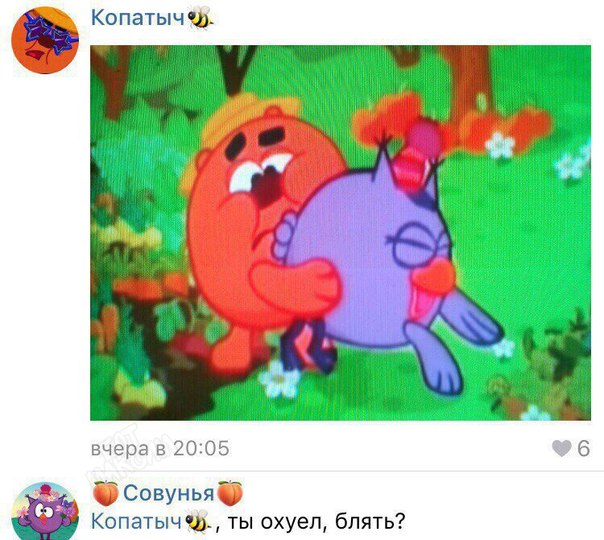

In [55]:
print(predict_fast("/content/drive/MyDrive/kopatych_bad.jpg", frozen=True))

Не токсичный


In [56]:
print(predict_fast("/content/drive/MyDrive/kopatych_bad.jpg"))

Токсичный


Пример безобидной картинки:

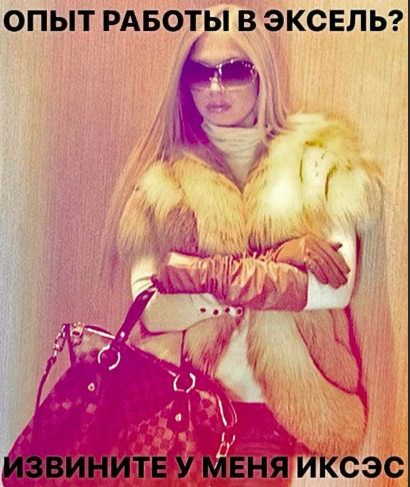

In [51]:
print(predict_fast("/content/drive/MyDrive/Image_33-excel.jpg", frozen=True))

Не токсичный


In [52]:
print(predict_fast("/content/drive/MyDrive/Image_33-excel.jpg"))

Не токсичный


**Перспективы для дальнейших исследований**

* Более современные OCR-модели для извлечения текста из картинки, возможно, обученные только на материалах русского языка, для качественных текстовых данных

* Пересмотр отношения к категориям токсичный / не токсичный на основании ошибок моделей

* Сбор большего датасета (10K+ изображений) для устойчивого обучения

* Ансамблирование нескольких моделей для повышения точности
